In [1]:
import pandas as pd

In [6]:
#读取数据
data = pd.read_csv("../data/advertising.csv")
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


In [7]:
# 数据预处理
data.dropna(inplace=True)
data.drop(data.columns[0],axis=1,inplace=True)
print(data.head())

#  data.columns[0]：要删除的第一列（按索引）
#axis=1：删除列（axis=0 表示删除行）
#inplace=True：在原数据上修改

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


In [10]:
# 定义特征
X = data.drop("Sales",axis=1)
Y = data["Sales"]
print(X.info())
print(Y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
dtypes: float64(3)
memory usage: 4.8 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 200 entries, 0 to 199
Series name: Sales
Non-Null Count  Dtype  
--------------  -----  
200 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB
None


In [11]:
r = X.corrwith(Y,method="pearson")
print(r)

TV           0.782224
Radio        0.576223
Newspaper    0.228299
dtype: float64


In [12]:
# 计算皮尔逊相关系数矩阵
corr_matrix = data.corr(method="pearson")
print(corr_matrix)

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.782224
Radio      0.054809  1.000000   0.354104  0.576223
Newspaper  0.056648  0.354104   1.000000  0.228299
Sales      0.782224  0.576223   0.228299  1.000000


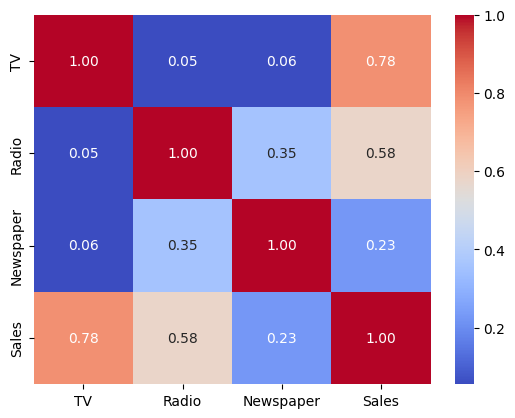

In [18]:
# 展示
import seaborn as sns
import matplotlib.pyplot as plt
# annot是否显示数值
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm")
plt.show()